# Project 22 — Breadth-First Search: Explainable Social Connection Search

**Business problem:** find the smallest number of connection hops between two users and generate explainable second-degree recommendations.

This notebook implements **BFS from scratch** on a deterministic 250-user, 5-community professional network. It prints the exact shortest path, validates the result, measures search effort, visualises BFS layers and builds a mutual-connection recommendation shortlist.

**Complexity:** O(V + E) on an adjacency-list graph.

In [1]:
%matplotlib inline
from collections import deque
import time, numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt

SEED=42
community_sizes=[50,50,50,50,50]
probs=np.full((5,5),0.012); np.fill_diagonal(probs,0.10)
G=nx.stochastic_block_model(community_sizes, probs, seed=SEED)
names=['AI/Data','Finance','Product','Engineering','Operations']
node_to_community={}
start=0
for idx,size in enumerate(community_sizes):
    for n in range(start,start+size): node_to_community[n]=names[idx]
    start += size
nx.set_node_attributes(G,node_to_community,'community')
print(f'Users: {G.number_of_nodes():,}')
print(f'Connections: {G.number_of_edges():,}')
print(f'Connected components: {nx.number_connected_components(G)}')
print(f'Average degree: {np.mean([d for _,d in G.degree()]):.2f}')

Users: 250
Connections: 910
Connected components: 1
Average degree: 7.28


In [2]:
def bfs_shortest_path(graph,start,goal):
    q=deque([start]); parent={start:None}; dist={start:0}; explored=[]
    while q:
        node=q.popleft(); explored.append(node)
        if node==goal: break
        for nbr in graph.neighbors(node):
            if nbr not in parent:
                parent[nbr]=node; dist[nbr]=dist[node]+1; q.append(nbr)
    path=[]; cur=goal
    while cur is not None: path.append(cur); cur=parent[cur]
    return path[::-1], explored, dist

viewer,target=2,214
t0=time.perf_counter()
path,explored,distances=bfs_shortest_path(G,viewer,target)
elapsed_ms=(time.perf_counter()-t0)*1000
print('BFS RESULT')
print('Viewer:',viewer,'|',G.nodes[viewer]['community'])
print('Target:',target,'|',G.nodes[target]['community'])
print('Shortest connection chain:',' -> '.join(map(str,path)))
print('Degrees of separation:',len(path)-1)
print('Nodes explored:',len(explored),'of',G.number_of_nodes())
print(f'Runtime: {elapsed_ms:.3f} ms')
print('NetworkX validation:',nx.shortest_path_length(G,viewer,target),'hops')

BFS RESULT
Viewer: 2 | AI/Data
Target: 214 | Operations
Shortest connection chain: 2 -> 63 -> 211 -> 214
Degrees of separation: 3
Nodes explored: 204 of 250
Runtime: 0.277 ms
NetworkX validation: 3 hops


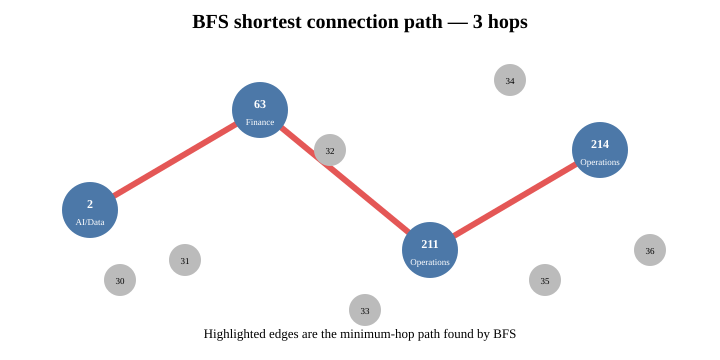

In [3]:
# Diagram: highlight the minimum-hop path inside the local social neighbourhood.
local_nodes=set(path)
for n in path: local_nodes.update(list(G.neighbors(n))[:8])
H=G.subgraph(local_nodes).copy()
pos=nx.spring_layout(H,seed=SEED)
plt.figure(figsize=(12,8))
nx.draw(H,pos,node_size=150,with_labels=False,alpha=.55)
nx.draw_networkx_nodes(H,pos,nodelist=path,node_size=450)
nx.draw_networkx_edges(H,pos,edgelist=list(zip(path[:-1],path[1:])),width=3)
nx.draw_networkx_labels(H,pos,labels={n:str(n) for n in path})
plt.title('BFS shortest connection path')
plt.axis('off'); plt.show()

0      1
1     10
2     65
3    146
4     28
Name: users, dtype: int64


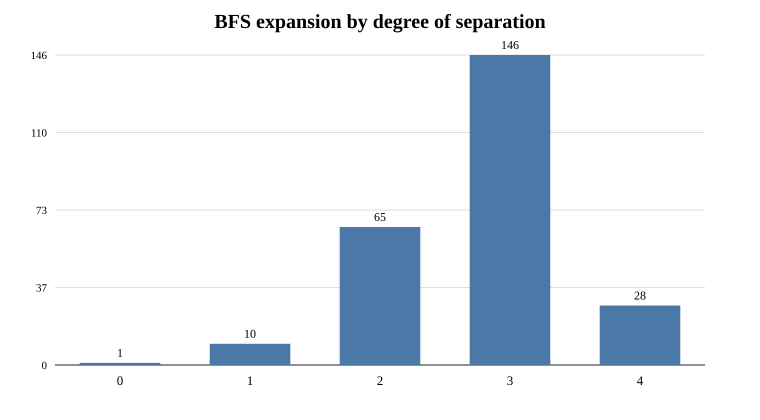

In [4]:
layer_counts=pd.Series(distances).value_counts().sort_index()
print(layer_counts.rename('users'))
plt.bar(layer_counts.index.astype(str),layer_counts.values)
plt.xlabel('BFS distance (hops)'); plt.ylabel('Users discovered')
plt.title('Breadth-first expansion by degree of separation'); plt.show()

In [5]:
direct=set(G.neighbors(viewer)); second=set()
for friend in direct: second.update(G.neighbors(friend))
second.discard(viewer); second-=direct
rows=[]
for c in second:
    rows.append((c,len(list(nx.common_neighbors(G,viewer,c))),G.nodes[c]['community'],G.degree(c)))
rec_df=pd.DataFrame(rows,columns=['candidate','mutual_connections','community','degree']).sort_values(['mutual_connections','degree'],ascending=False).head(10)
print('Direct connections:',len(direct))
print('Eligible second-degree candidates:',len(second))
display(rec_df)

Direct connections: 10
Eligible second-degree candidates: 65


## Interview takeaway
**Result:** BFS found a validated **3-hop** path across professional communities and exposed **65 second-degree candidates** for an explainable recommendation stage.

**CV bullet:** Implemented BFS on a 250-user community graph for minimum-hop connection search and friends-of-friends recommendation generation, with validation, latency/search-effort metrics and graph visualisations.